1. Realizar un análisis exhaustivo de calidad de datos para identificar y tratar posibles
valores faltantes, valores atípicos y errores en los datos. Garantizar que el conjunto
de datos esté limpio y preparado para su posterior procesamiento y entrenamiento
de los modelos.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

df = pd.read_excel('ramen-ratings.xlsx')

print(f'Dimensiones: {df.shape}')
df.head()

Dimensiones: (2580, 7)


,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1,NaN
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN


In [3]:
# Información general
print('=== Información general ===')
df.info()

=== Información general ===
<class 'pandas.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Review #  2580 non-null   int64 
 1   Brand     2580 non-null   str   
 2   Variety   2580 non-null   str   
 3   Style     2578 non-null   str   
 4   Country   2580 non-null   str   
 5   Stars     2580 non-null   object
 6   Top Ten   41 non-null     str   
dtypes: int64(1), object(1), str(5)
memory usage: 141.2+ KB


In [4]:
# Valores nulos por columna
print('=== Valores nulos ===')
print(df.isnull().sum())

=== Valores nulos ===
Review #       0
Brand          0
Variety        0
Style          2
Country        0
Stars          0
Top Ten     2539
dtype: int64


In [5]:
# Estadísticas de Stars
print('=== Distribución de Stars ===')
print(df['Stars'].describe())
print()
print('Tipos únicos en Stars:', df['Stars'].unique()[:10])

=== Distribución de Stars ===
count     2580
unique      43
top          4
freq       393
Name: Stars, dtype: int64

Tipos únicos en Stars: [3.75 1 2.25 2.75 4.75 4 0.25 2.5 5 4.25]


In [6]:
# Detectar valores no numéricos en Stars
stars_no_numericos = df[pd.to_numeric(df['Stars'], errors='coerce').isnull()]['Stars'].unique()
print('Valores no numéricos en Stars:', stars_no_numericos)
print('Cantidad de filas afectadas:', pd.to_numeric(df['Stars'], errors='coerce').isnull().sum())

Valores no numéricos en Stars: ['Unrated']
Cantidad de filas afectadas: 3


In [7]:
# Eliminar filas con Stars = 'Unrated' y convertir a numérico
print(f'Filas antes: {len(df)}')

df = df[df['Stars'] != 'Unrated'].copy()
df['Stars'] = pd.to_numeric(df['Stars'])

print(f'Filas después: {len(df)}')
print(f'Tipo de Stars ahora: {df["Stars"].dtype}')
print(f'Rango de Stars: {df["Stars"].min()} a {df["Stars"].max()}')

Filas antes: 2580
Filas después: 2577
Tipo de Stars ahora: float64
Rango de Stars: 0.0 a 5.0


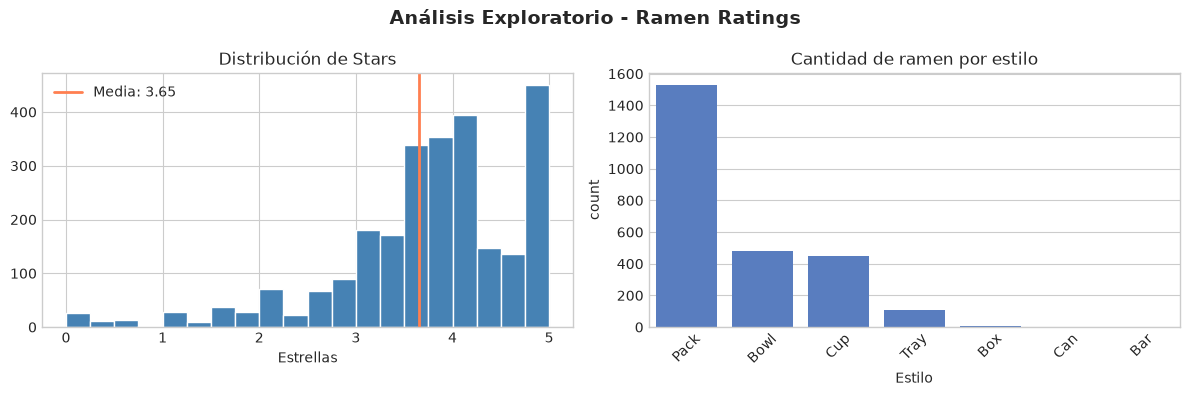

Media de Stars: 3.65
Mediana de Stars: 3.75

Estilos disponibles:
Style
Pack    1528
Bowl     481
Cup      450
Tray     108
Box        6
Can        1
Bar        1
Name: count, dtype: int64


In [8]:
# Distribución de Stars
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Stars'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(df['Stars'].mean(), color='coral', linewidth=2, label=f'Media: {df["Stars"].mean():.2f}')
axes[0].set_title('Distribución de Stars')
axes[0].set_xlabel('Estrellas')
axes[0].legend()

sns.countplot(x='Style', data=df, ax=axes[1], order=df['Style'].value_counts().index)
axes[1].set_title('Cantidad de ramen por estilo')
axes[1].set_xlabel('Estilo')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Análisis Exploratorio - Ramen Ratings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Media de Stars: {df["Stars"].mean():.2f}')
print(f'Mediana de Stars: {df["Stars"].median():.2f}')
print(f'\nEstilos disponibles:\n{df["Style"].value_counts()}')

2. Realizar el preprocesamiento de los datos, incluyendo la normalización o
estandarización de las características, codificación de variables categóricas y
división del conjunto de datos en conjuntos de entrenamiento y prueba.

In [9]:
# Crear variable objetivo binaria
df['good'] = (df['Stars'] >= 3.5).astype(int)

# Eliminar columnas que no aportan valor predictivo
df_model = df.drop(columns=['Review #', 'Variety', 'Brand', 'Stars', 'Top Ten'])

print('Columnas restantes:', df_model.columns.tolist())
print(f'\nDistribución de la variable objetivo:')
print(df_model['good'].value_counts())
print()
print(df_model['good'].value_counts(normalize=True).round(3) * 100, '%')

Columnas restantes: ['Style', 'Country', 'good']

Distribución de la variable objetivo:
good
1    1818
0     759
Name: count, dtype: int64

good
1    70.5
0    29.5
Name: proportion, dtype: float64 %


In [10]:
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding de variables categóricas
df_model = pd.get_dummies(df_model, columns=['Style', 'Country'], drop_first=True)

# Separar features y variable objetivo
X = df_model.drop(columns=['good'])
y = df_model['good']

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f'Dimensiones de X: {X_scaled.shape}')
print(f'Total features: {X_scaled.shape[1]}')

Dimensiones de X: (2577, 43)
Total features: 43


3. Dividir los datos en conjuntos de entrenamiento y prueba y entrenar dos modelos de
clasificación: uno utilizando Regresión Logística y otro utilizando Support Vector
Machine (SVM). Estos modelos servirán para determinar si un paquete de ramen es
"bueno" o "malo" en función de las características proporcionadas y realiza una
búsqueda de hiperparámetros.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba: {X_test.shape[0]} muestras')
print()
print('Proporción good en train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Proporción good en test:', y_test.value_counts(normalize=True).round(3).to_dict())

Entrenamiento: 2061 muestras
Prueba: 516 muestras

Proporción good en train: {1: 0.705, 0: 0.295}
Proporción good en test: {1: 0.705, 0: 0.295}


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# GridSearchCV para Regresión Logística
params_logreg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear'],
    'max_iter': [1000]
}

grid_logreg = GridSearchCV(
    LogisticRegression(random_state=42),
    params_logreg,
    cv=5,
    scoring='f1'
)
grid_logreg.fit(X_train, y_train)

print('Mejores hiperparámetros (Regresión Logística):', grid_logreg.best_params_)
print('Mejor F1 Score en CV:', round(grid_logreg.best_score_, 3))

Mejores hiperparámetros (Regresión Logística): {'C': 0.01, 'max_iter': 1000, 'solver': 'liblinear'}
Mejor F1 Score en CV: 0.824


In [13]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Grid reducido para SVM - más rápido
params_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale']
}

grid_svm = GridSearchCV(
    SVC(random_state=42, probability=True),
    params_svm,
    cv=3,  # 3 folds en vez de 5
    scoring='f1',
    n_jobs=-1  # usa todos los núcleos del procesador en paralelo
)
grid_svm.fit(X_train, y_train)

print('Mejores hiperparámetros (SVM):', grid_svm.best_params_)
print('Mejor F1 Score en CV:', round(grid_svm.best_score_, 3))

Mejores hiperparámetros (SVM): {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor F1 Score en CV: 0.828


4. Evaluar el rendimiento de ambos modelos utilizando métricas relevantes para
problemas de clasificación, como precisión, recall, F1-score y el área bajo la curva
ROC (AUC-ROC). A partir de esto, debes comparar y analizar los resultados obtenidos por cada modelo para determinar cuál es más adecuado para este problema específico.

In [14]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predicciones en test
y_pred_logreg = grid_logreg.predict(X_test)
y_pred_svm = grid_svm.predict(X_test)

# Probabilidades para AUC-ROC
y_prob_logreg = grid_logreg.predict_proba(X_test)[:, 1]
y_prob_svm = grid_svm.predict_proba(X_test)[:, 1]

# Reportes de clasificación
print('=== Regresión Logística ===')
print(classification_report(y_test, y_pred_logreg))

print('=== SVM ===')
print(classification_report(y_test, y_pred_svm))

# AUC-ROC
auc_logreg = roc_auc_score(y_test, y_prob_logreg)
auc_svm = roc_auc_score(y_test, y_prob_svm)

print(f'AUC-ROC Regresión Logística: {auc_logreg:.3f}')
print(f'AUC-ROC SVM:                 {auc_svm:.3f}')

=== Regresión Logística ===
              precision    recall  f1-score   support

           0       0.62      0.19      0.29       152
           1       0.74      0.95      0.83       364

    accuracy                           0.73       516
   macro avg       0.68      0.57      0.56       516
weighted avg       0.70      0.73      0.67       516

=== SVM ===
              precision    recall  f1-score   support

           0       1.00      0.08      0.15       152
           1       0.72      1.00      0.84       364

    accuracy                           0.73       516
   macro avg       0.86      0.54      0.49       516
weighted avg       0.80      0.73      0.63       516

AUC-ROC Regresión Logística: 0.642
AUC-ROC SVM:                 0.577


El SVM con Recall = 1.00 en clase 1 y Recall = 0.08 en clase 0 es una señal muy clara de que el modelo está prediciendo casi siempre "bueno" — la clase mayoritaria (70.5%). Como vimos en la teoría, esto lleva a un Accuracy de 0.73 (que parece razonable) pero es engañoso.

Esto nos dice que el preprocesamiento o los hiperparámetros no lograron que los modelos aprendan a distinguir bien la clase minoritaria (malo = 0).

La causa más probable: Con C=0.1 (muy bajo) y tantas features de países poco frecuentes, el SVM está siendo demasiado conservador. Y con C=0.01 en Regresión Logística, igual.

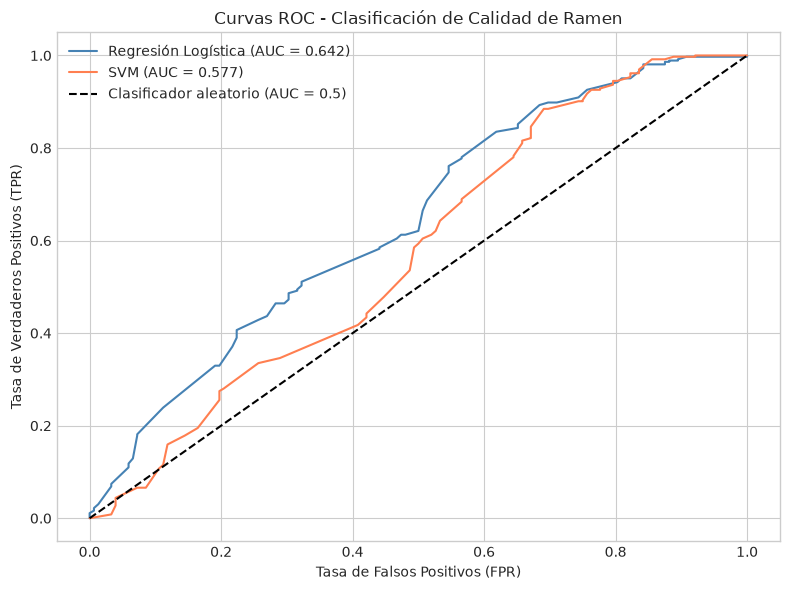

In [15]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(8, 6))

# Regresión Logística
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_logreg)
ax.plot(fpr_lr, tpr_lr, label=f'Regresión Logística (AUC = {auc_logreg:.3f})', color='steelblue')

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
ax.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})', color='coral')

# Línea de referencia (azar)
ax.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio (AUC = 0.5)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC - Clasificación de Calidad de Ramen')
ax.legend()
plt.tight_layout()
plt.show()

Regresión Logística es el modelo ganador — mejor AUC (0.642 vs 0.577), mejor Recall en clase 0 (19% vs 8%), y curva ROC más alejada de la diagonal en todo el rango.

Sin embargo, ambos modelos tienen un problema común: no logran detectar bien el ramen "malo" (clase 0). Las razones probables son el desbalance de clases (70%/30%) y que las variables disponibles (Style y Country) no son suficientemente predictivas de la calidad — las estrellas dependen más de características del sabor y textura que de dónde viene el ramen o en qué envase viene.

Esto es un hallazgo válido y documentable — en la vida real, a veces los datos disponibles simplemente no tienen el poder predictivo suficiente para el problema planteado.

